<a href="https://colab.research.google.com/github/kushalhole/Data_science_lab_SE_20/blob/main/ds_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/retail_sales_dataset.csv')

# Display the first 5 rows to understand the data structure
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


The dataset has been loaded and the first few rows are displayed for initial inspection. Now, I will calculate the total sales and total units sold.

In [ ]:
# Ensure 'Price per Unit' and 'Quantity' are numeric for calculations
df['Price per Unit'] = pd.to_numeric(df['Price per Unit'], errors='coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')

# 'Total Amount' already exists and represents total sales per transaction. Assign it to 'Total Sales' for consistency.
df['Total Sales'] = df['Total Amount']

# Calculate Total Sales and Total Units Sold
total_sales = df['Total Sales'].sum()
total_units_sold = df['Quantity'].sum()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Units Sold: {total_units_sold:,.0f}")

Total Sales: $456,000.00
Total Units Sold: 2,514


The total sales and units sold have been calculated. Next, I will identify the top 5 products by sales, calculate sales by region, and analyze the monthly sales trend.

In [ ]:
# Top 5 Products by Sales
top_5_products = df.groupby('Product Category')['Total Sales'].sum().nlargest(5).reset_index()
print("\nTop 5 Products by Sales:")
display(top_5_products)

# Monthly Sales Trend
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])
monthly_sales = df.set_index('Date').resample('M')['Total Sales'].sum().reset_index()
monthly_sales['Month'] = monthly_sales['Date'].dt.strftime('%Y-%m')
print("\nMonthly Sales Trend:")
display(monthly_sales)


Top 5 Products by Sales:


,Product Category,Total Sales
0,Electronics,156905
1,Clothing,155580
2,Beauty,143515



Monthly Sales Trend:


/tmp/ipykernel_5235/4108733697.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.set_index('Date').resample('M')['Total Sales'].sum().reset_index()


,Date,Total Sales,Month
0,2023-01-31,35450,2023-01
1,2023-02-28,44060,2023-02
2,2023-03-31,28990,2023-03
3,2023-04-30,33870,2023-04
4,2023-05-31,53150,2023-05
5,2023-06-30,36715,2023-06
6,2023-07-31,35465,2023-07
7,2023-08-31,36960,2023-08
8,2023-09-30,23620,2023-09
9,2023-10-31,46580,2023-10


The key metrics have been calculated and displayed. Now, I will visualize these insights using different chart types.

/tmp/ipykernel_5235/1845209632.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Product Category', y='Total Sales', data=top_5_products, palette='viridis')


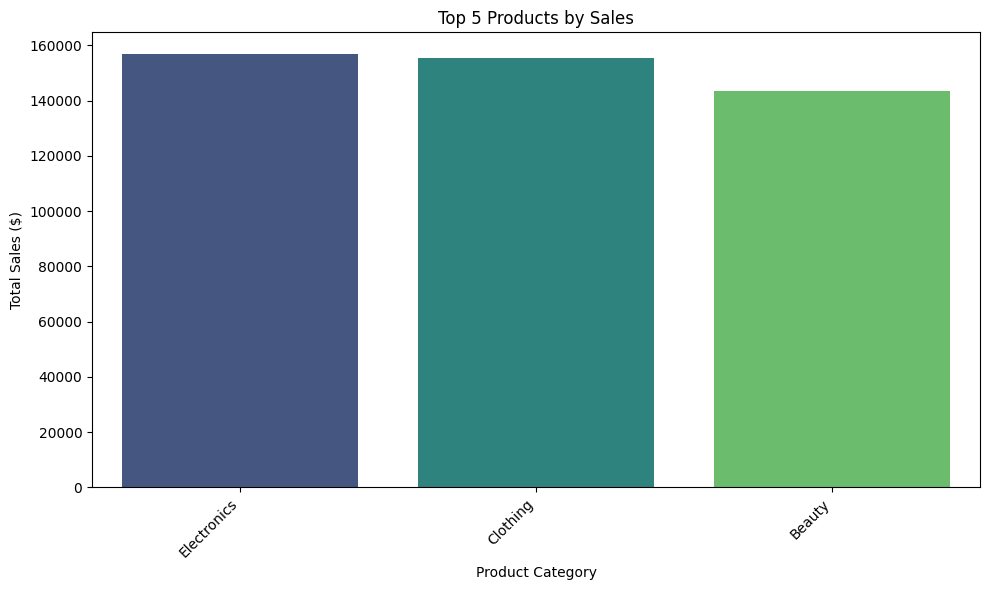

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Product Category', y='Total Sales', data=top_5_products, palette='viridis')
plt.title('Top 5 Products by Sales')
plt.xlabel('Product Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# The 'Region' column was not found in the dataset, so sales by region cannot be plotted.

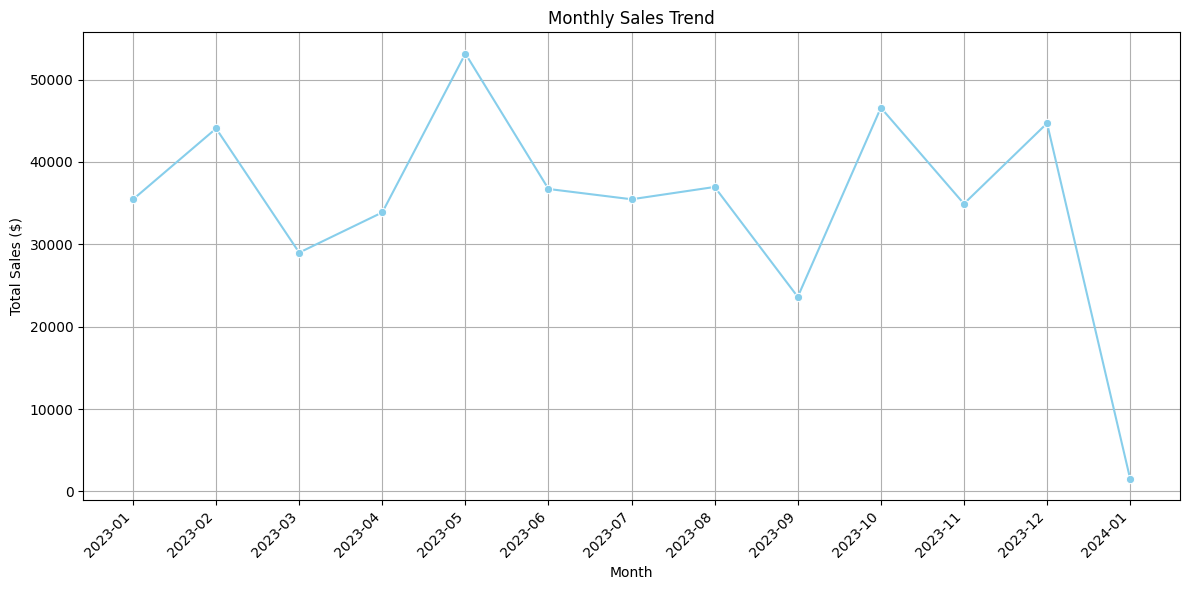

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Month', y='Total Sales', data=monthly_sales, marker='o', color='skyblue')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()